In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [126]:
#Lo que intentaremos hacer primero es analizar y
# e intentar responer algunas preguntas

df = pd.read_csv('supermarket_sales.csv')
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [127]:
df.isnull().sum().sum()

np.int64(0)

In [128]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [129]:
print("Filas y columnas:", df.shape)

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nDuplicados:", df.duplicated().sum())

Filas y columnas: (1000, 17)

Valores faltantes:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Duplicados: 0


In [130]:
#¿Que ciudad vende más?
df['City'].unique()

array(['Yangon', 'Naypyitaw', 'Mandalay'], dtype=object)

In [131]:
#¿Que ciudad vende más?

ciudad_ventas = df.groupby("City")["Total"].sum()
print(ciudad_ventas)

ciudad_top = ciudad_ventas.idxmax()
dinero_ciudad = ciudad_ventas.max()

print(ciudad_top,"generó:" ,dinero_ciudad)

City
Mandalay     106197.6720
Naypyitaw    110568.7065
Yangon       106200.3705
Name: Total, dtype: float64
Naypyitaw generó: 110568.7065


In [132]:
#¿Que tipo de tipo de productos hay?
df["Product line"].unique()

array(['Health and beauty', 'Electronic accessories',
       'Home and lifestyle', 'Sports and travel', 'Food and beverages',
       'Fashion accessories'], dtype=object)

In [133]:
#¿En que linea se venden más productos?

linea_productos = df.groupby('Product line')["Total"].sum()
print(linea_productos)

linea_top = linea_productos.idxmax()
dinero_productos = linea_productos.max()

print("La linea",linea_top,"generó:",dinero_productos)

Product line
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Food and beverages        56144.8440
Health and beauty         49193.7390
Home and lifestyle        53861.9130
Sports and travel         55122.8265
Name: Total, dtype: float64
La linea Food and beverages generó: 56144.844


In [134]:
#Que producto casi no se venden?

linea_menos = linea_productos.idxmin()
dinero_linea_menos = linea_productos.min()

print("La que menos generó fue:", linea_menos,"y generó:",dinero_linea_menos)

La que menos generó fue: Health and beauty y generó: 49193.739


In [135]:
#¿Hubo un dia donde se vendiera más?
df['Date'].value_counts()

,count
Date,
2/7/2019,20
2/15/2019,19
3/2/2019,18
1/8/2019,18
3/14/2019,18
...,...
2/1/2019,6
1/4/2019,6
3/21/2019,6


In [136]:
#Si hubo un dia donde se vendio más

dia_mas_ventas = df['Date'].value_counts().idxmax()
print("El dia que mas se vendio:",dia_mas_ventas)

El dia que mas se vendio: 2/7/2019


In [137]:
#Metodos de pago

metodo_pago= df['Payment'].value_counts()
top_metodo_pago = df['Payment'].value_counts().idxmax()

print(top_metodo_pago)

tot_top_metodo_pago = df['Payment'].value_counts().max()
print(tot_top_metodo_pago)

Ewallet
345


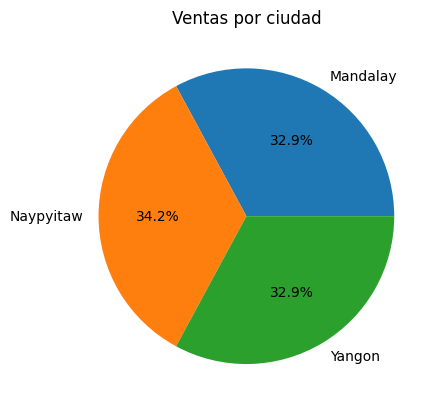

In [138]:
plt.pie(ciudad_ventas, labels = ciudad_ventas.index, autopct="%1.1f%%")
plt.title("Ventas por ciudad")
plt.show()

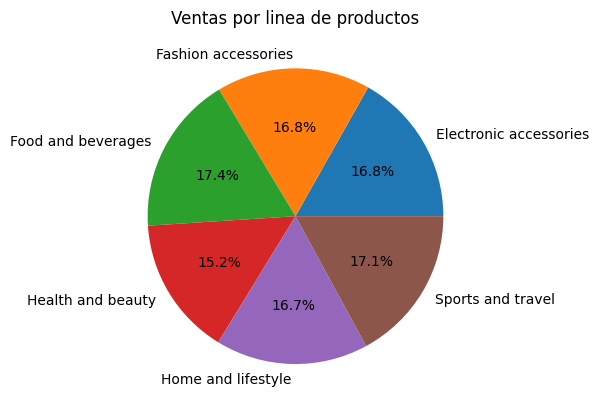

In [139]:
plt.pie(linea_productos, labels = linea_productos.index, autopct="%1.1f%%")
plt.title("Ventas por linea de productos")
plt.show()

In [140]:
print(df['Date'].min())
print(df['Date'].max())

1/1/2019
3/9/2019


In [141]:
df["Date"] = pd.to_datetime(df["Date"])

In [142]:
df['Date'].dt.month.unique()

array([1, 3, 2], dtype=int32)

In [143]:
ventas_mes = df.groupby(df['Date'].dt.month)['Total'].sum()

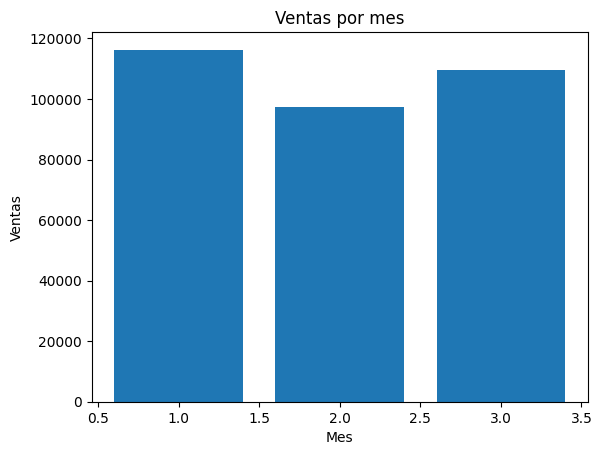

In [144]:
plt.bar(ventas_mes.index, ventas_mes.values)
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.title("Ventas por mes")
plt.show()

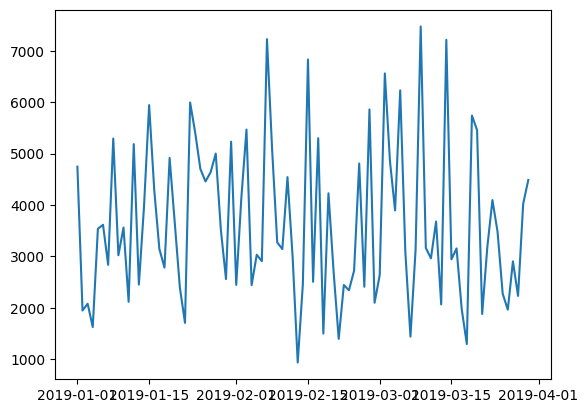

In [145]:
ventas_dia = df.groupby('Date')['Total'].sum()
plt.plot(ventas_dia.index, ventas_dia.values)

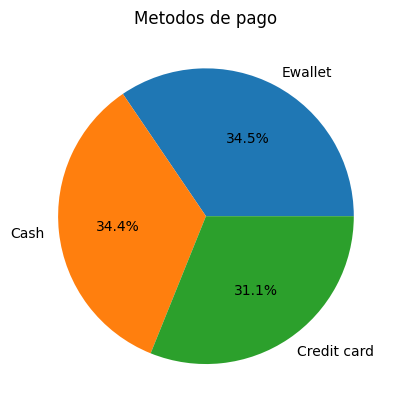

In [146]:
plt.pie(metodo_pago, labels=metodo_pago.index, autopct="%1.1f%%")
plt.title("Metodos de pago")
plt.show()

In [147]:
ventas_genero = df.groupby("Gender")["Total"].sum()

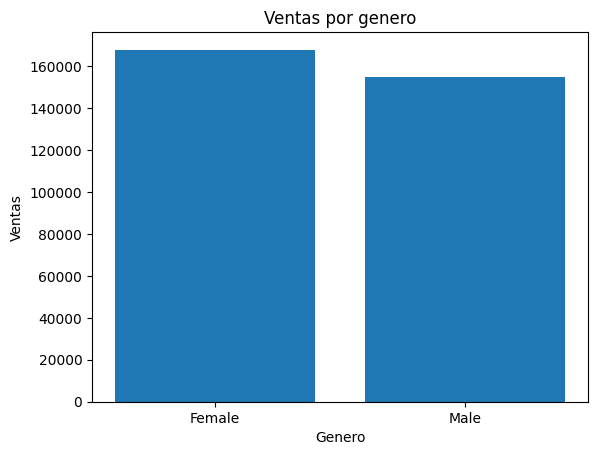

In [148]:
plt.bar(ventas_genero.index, ventas_genero.values)
plt.xlabel("Genero")
plt.ylabel("Ventas")
plt.title("Ventas por genero")
plt.show()

In [149]:
hombres = df[df['Gender'] == 'Male']
mujeres = df[df['Gender'] == 'Female']

In [150]:
compras_hombres = hombres.groupby('Product line')['Total'].sum()
print(compras_hombres)

top_compras_hombres = compras_hombres.idxmax()
total_compras_hombres = compras_hombres.max()

print("Los hombres compraron mas la linea de:", top_compras_hombres, "y comprarón",total_compras_hombres)


Product line
Electronic accessories    27235.5090
Fashion accessories       23868.4950
Food and beverages        22973.9265
Health and beauty         30632.7525
Home and lifestyle        23825.0355
Sports and travel         26548.1055
Name: Total, dtype: float64
Los hombres compraron mas la linea de: Health and beauty y comprarón 30632.7525


In [151]:
compras_mujeres = mujeres.groupby('Product line')['Total'].sum()
print(compras_mujeres)

top_compras_mujeres = compras_mujeres.idxmax()
total_compras_mujeres = compras_mujeres.max()

print("Las mujeres compraron mas la linea de:", top_compras_mujeres, "y gastaron:", total_compras_mujeres)

Product line
Electronic accessories    27102.0225
Fashion accessories       30437.4000
Food and beverages        33170.9175
Health and beauty         18560.9865
Home and lifestyle        30036.8775
Sports and travel         28574.7210
Name: Total, dtype: float64
Las mujeres compraron mas la linea de: Food and beverages y gastaron: 33170.9175


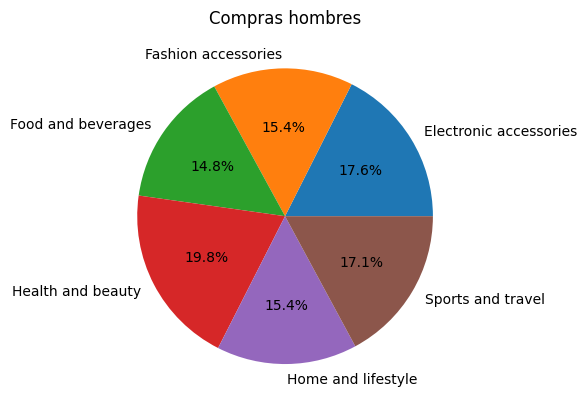

In [152]:
plt.pie(compras_hombres, labels=compras_hombres.index, autopct="%1.1f%%")
plt.title("Compras hombres")
plt.show()

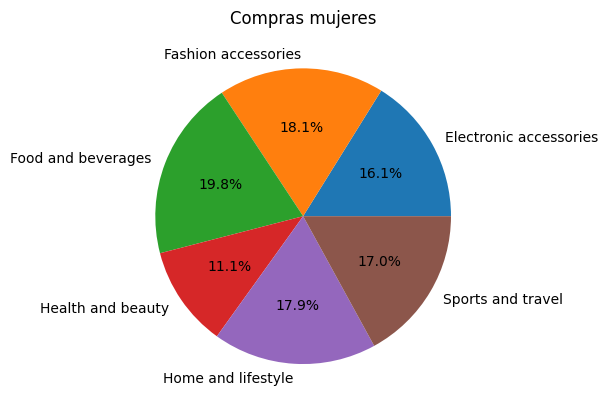

In [153]:
plt.pie(compras_mujeres, labels=compras_mujeres.index, autopct="%1.1f%%")
plt.title("Compras mujeres")
plt.show()

In [154]:
df.groupby('Gender')['Customer type'].value_counts()

Gender  Customer type
Female  Member           261
        Normal           240
Male    Normal           259
        Member           240
Name: count, dtype: int64

Customer type
Normal    259
Member    240
Name: count, dtype: int64


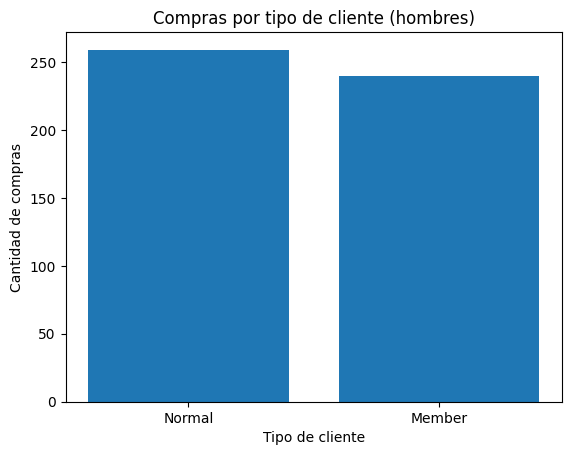

In [155]:
tipo_hombres = hombres["Customer type"].value_counts()
print(tipo_hombres)

plt.bar(tipo_hombres.index, tipo_hombres.values)
plt.title('Compras por tipo de cliente (hombres)')
plt.xlabel('Tipo de cliente')
plt.ylabel('Cantidad de compras')
plt.show()


Customer type
Member    261
Normal    240
Name: count, dtype: int64


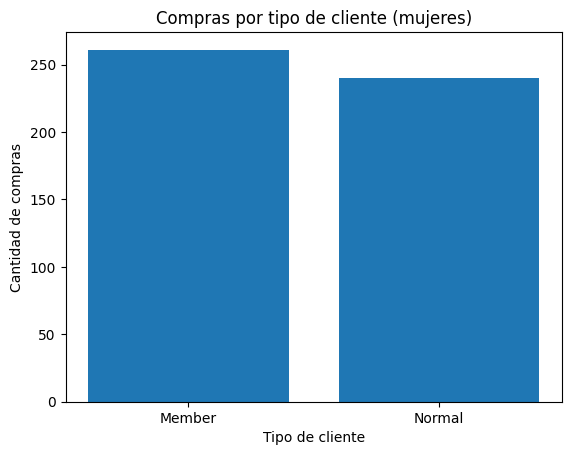

In [156]:
tipo_mujeres = mujeres["Customer type"].value_counts()
print(tipo_mujeres)

plt.bar(tipo_mujeres.index, tipo_mujeres.values)
plt.title('Compras por tipo de cliente (mujeres)')
plt.xlabel('Tipo de cliente')
plt.ylabel('Cantidad de compras')
plt.show()

## Business Insights

El análisis exploratorio de los datos de ventas permite identificar varios patrones interesantes en el comportamiento de los clientes.

En primer lugar, las ventas entre las tres ciudades analizadas se mantienen relativamente estables, sin diferencias drásticas en los ingresos generados por cada sucursal. Esto sugiere que el desempeño comercial es bastante consistente entre las distintas ubicaciones.

De forma similar, las ventas por línea de producto presentan variaciones moderadas, aunque algunas categorías muestran un desempeño ligeramente superior. Sin embargo, no se observan diferencias extremadamente marcadas entre las categorías.

En cuanto al comportamiento de compra por género, se identifican ciertas preferencias:

Los hombres muestran una mayor preferencia por la línea de productos "Health and Beauty".

Las mujeres tienden a comprar con mayor frecuencia productos de la categoría "Food and Beverages".

También se observa una ligera diferencia en el tipo de cliente. Las mujeres presentan una proporción ligeramente mayor de clientes con membresía, mientras que los hombres parecen realizar compras con mayor frecuencia sin membresía. Esto podría indicar una oportunidad de negocio para incentivar a más clientes masculinos a adquirir membresías, analizando qué factores influyen en la mayor adopción de estas por parte de las mujeres.

Respecto a la evolución temporal de las ventas, se observa una disminución en febrero en comparación con enero y marzo. Este comportamiento podría estar relacionado con factores estacionales o patrones de consumo específicos de ese periodo.

Finalmente, en cuanto a los métodos de pago, el análisis muestra que los clientes prefieren utilizar billeteras electrónicas (e-wallet) sobre otros métodos de pago, aunque la diferencia con los demás métodos no es particularmente grande.

En general, el análisis permite identificar patrones de comportamiento del cliente que podrían utilizarse para mejorar estrategias de marketing, promociones y programas de fidelización.